In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.cluster import MeanShift, estimate_bandwidth

In [2]:
address = ""
all_files = glob.glob(address+'images/train_mini3/*.png')
img_row_size = 67
img_col_size = 48
img_size = img_row_size*img_col_size

In [3]:
img_data = []
for i in range(len(all_files)):
    img_color = cv.imread(all_files[i], cv.IMREAD_COLOR)
    img_color = cv.resize(cv.cvtColor(img_color, cv.COLOR_BGR2RGB), (img_col_size, img_row_size))[0:40,15:40,:]
    R = img_color[:, :, 0].astype(int)
    G = img_color[:, :, 1].astype(int)
    B = img_color[:, :, 2].astype(int)
    weighted_image = 1.0 * R - 1.0 * G - 1.0 * B
    weighted_image[weighted_image < 0] = 0

    img_data += [weighted_image]
    #img_gray = cv.imread(all_files[i], cv.IMREAD_GRAYSCALE)
    #img_data += [cv.resize(img_gray, (img_col_size, img_row_size))[0:40,15:40]]

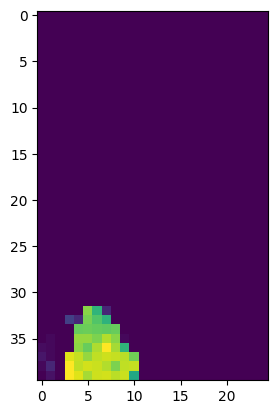

In [4]:
# Key part of the code for forming the rules

eg = 0

X = []
for i in range(len(img_data[eg])):
    for j in range(len(img_data[eg][0])):
        for k in range(int((img_data[eg][i][j])/50)):
            X += [[max(0.001,j+np.random.randn(1)[0]/5),max(0.001,i+np.random.randn(1)[0]/5)]]
X = np.array(X)

plt.imshow(img_data[eg])

Number of estimated clusters: 1
Cluster centers:
 [[ 6.21638308 36.39531185]]


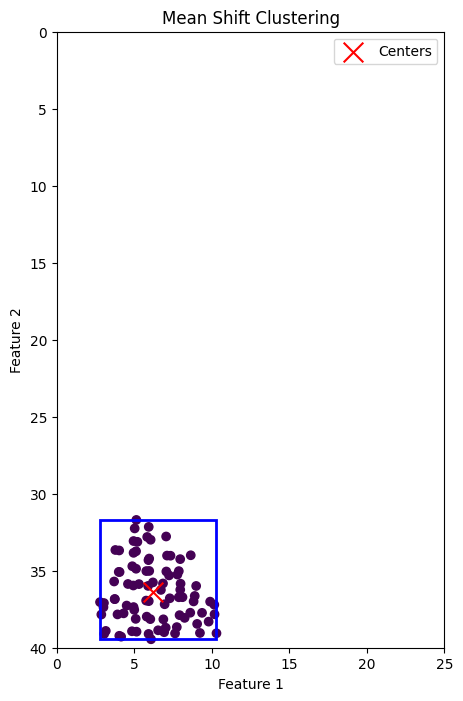

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [2.78, 31.7, 10.3, 39.45, 1.0]


In [5]:
# Bandwidth Estimation

# bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=len(X))
bandwidth = 6

# Performing MeanShift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

# Finding the Cluster Centers
cluster_centers = ms.cluster_centers_
labels = ms.labels_

# Normal Cluster Probability
cluster_probabilities = []
total_data_points = len(X)
for label in np.unique(labels):
    cluster_points = X[labels == label]
    num_points = len(cluster_points)
    probability = num_points / total_data_points
    cluster_probabilities.append(probability)
cluster_probabilities = np.array(cluster_probabilities)/np.max(cluster_probabilities)

# Finding the Number of Clusters
n_clusters_ = len(np.unique(labels))

# Print Cluster Centers
print(f"Number of estimated clusters: {n_clusters_}")
print("Cluster centers:\n", cluster_centers)

# Visualization
plt.figure(figsize=(5, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='red', s=200, label='Centers')

# Bounding Boxes
bounding_boxes = []
for label in np.unique(labels):
    cluster_points = X[labels == label]
    min_x, min_y = cluster_points.min(axis=0)
    max_x, max_y = cluster_points.max(axis=0)
    bounding_box = [np.round(min_x,2), np.round(min_y,2), np.round(max_x,2), np.round(max_y,2), np.round(cluster_probabilities[label],2)]
    bounding_boxes.append(bounding_box)
    rect = plt.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, fill=False, edgecolor='blue', linewidth=2)
    plt.gca().add_patch(rect)

# Graph Settings
plt.xlim([0,25])
plt.ylim([0,40])
plt.title('Mean Shift Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

# Print Bounding Boxes
print("Bounding Boxes [left x, top y, right x, bottom y]:")
for i, bbox in enumerate(bounding_boxes):
    print(f"Cluster {i}: {bbox}")

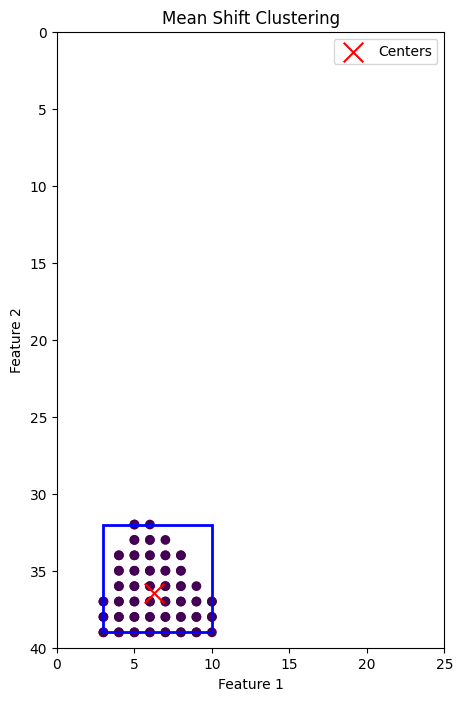

Cluster 0: [3, 32, 10, 39, 1.0, 1]
Count 0


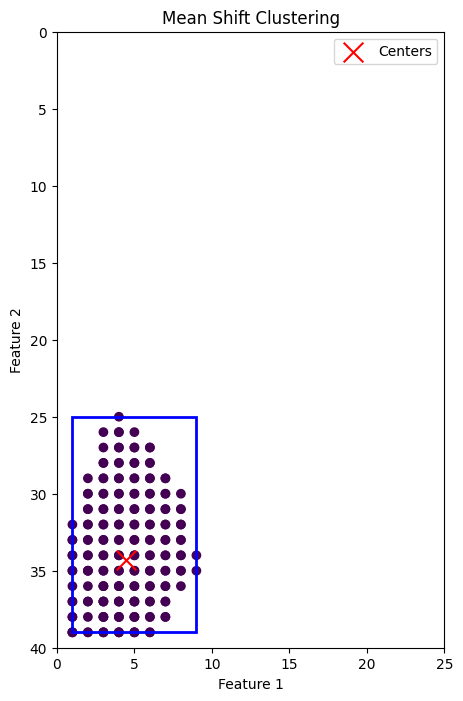

Cluster 0: [1, 25, 9, 39, 1.0, 0]
Count 1


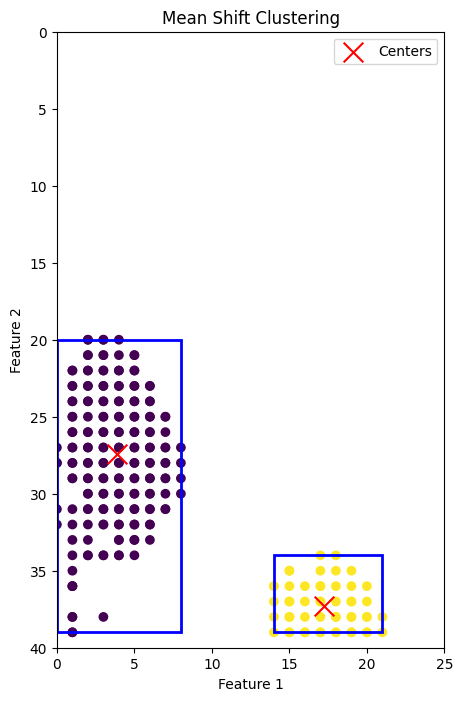

Cluster 0: [0, 20, 8, 39, 1.0, 1]
Cluster 1: [14, 34, 21, 39, 0.29, 1]
Count 1


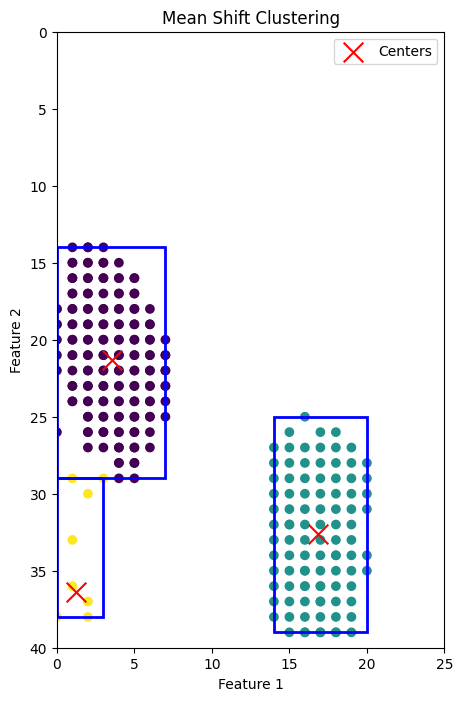

Cluster 0: [0, 14, 7, 29, 1.0, 1]
Cluster 1: [14, 25, 20, 39, 0.6, 0]
Count 2


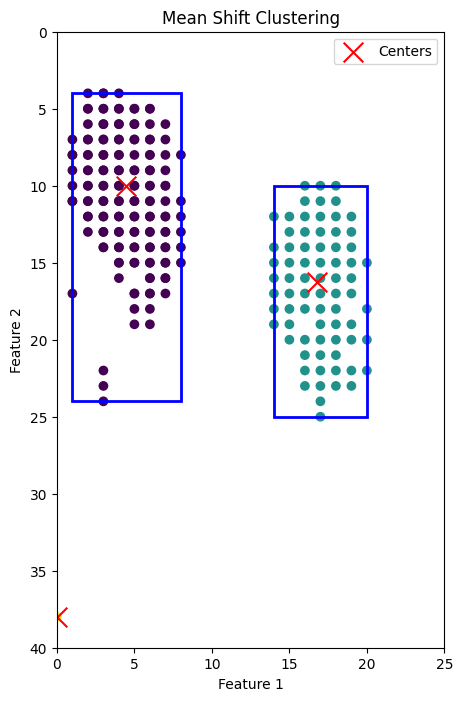

Cluster 0: [1, 4, 8, 24, 1.0, 1]
Cluster 1: [14, 10, 20, 25, 0.49, 1]
Count 2


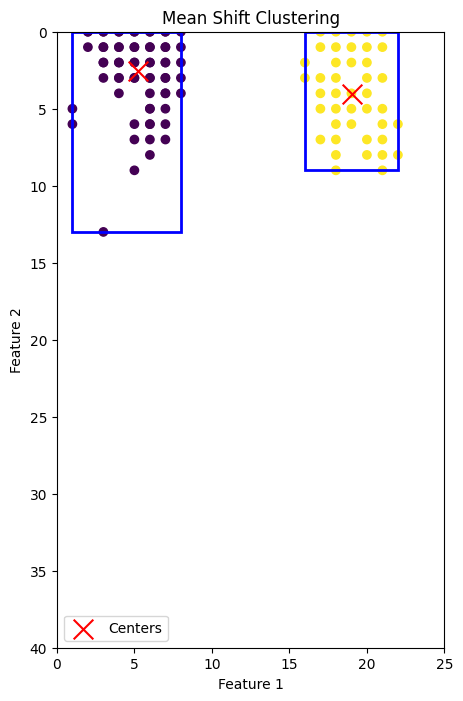

Cluster 0: [1, 0, 8, 13, 1.0, 1]
Cluster 1: [16, 0, 22, 9, 0.64, 1]
Count 2


In [6]:
# Assuming the camera's frame rate is sufficiently high.

frames = {}; frames[0] = []
count = 0
for f in range(len(all_files)):
    X = []
    for i in range(len(img_data[f])):
        for j in range(len(img_data[f][0])):
            for k in range(int((img_data[f][i][j])/50)):
                #X += [[max(0.001,j+np.random.randn(1)[0]/5),max(0.001,i+np.random.randn(1)[0]/5)]]
                X += [[j,i]]
    X = np.array(X)
    
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(X)
    
    # Finding the Cluster Centers
    cluster_centers = ms.cluster_centers_
    labels = ms.labels_
    
    # Normal Cluster Probability
    cluster_probabilities = []
    total_data_points = len(X)
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        num_points = len(cluster_points)
        probability = num_points / total_data_points
        cluster_probabilities.append(probability)
    cluster_probabilities = np.array(cluster_probabilities)/np.max(cluster_probabilities)
    
    # Finding the Number of Clusters
    n_clusters_ = len(np.unique(labels))
    
    # Visualization
    plt.figure(figsize=(5, 8))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
    plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='red', s=200, label='Centers')
    
    # Bounding Boxes
    bounding_boxes = []
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        min_x, min_y = cluster_points.min(axis=0)
        max_x, max_y = cluster_points.max(axis=0)
        bounding_box = [np.round(min_x,2), np.round(min_y,2), np.round(max_x,2), np.round(max_y,2), np.round(cluster_probabilities[label],2), 1]
        bounding_boxes.append(bounding_box)
        rect = plt.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, fill=False, edgecolor='blue', linewidth=2)
        plt.gca().add_patch(rect)
    frames[f+1] = bounding_boxes

    current_boxes = frames[f+1]
    previous_boxes = frames[f]
    
    for i, current_box in enumerate(current_boxes):
        if current_box[3]==39 and current_box[4]>=0.1:
            current_min_x, current_min_y, current_max_x, current_max_y, current_prob, current_count = current_box
            similar_boxes = [
                bbox for bbox in previous_boxes
                if abs(bbox[0] - current_min_x) <= 3 and abs(bbox[2] - current_max_x) <= 3 and bbox[5]==1
            ]
            
            for prev_box in similar_boxes:
                prev_min_x, prev_min_y, prev_max_x, prev_max_y, prev_prob, prev_count = prev_box
                prev_height = prev_max_y - prev_min_y
                current_height = current_max_y - current_min_y
                
                if current_height > prev_height:
                    count += 1
                    frames[f+1][i][5] = 0
                elif current_height < prev_height:
                    count -= 1
                    frames[f+1][i][5] = 0
    
    # Graph Settings
    plt.xlim([0,25])
    plt.ylim([0,40])
    plt.title('Mean Shift Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()
    
    # Print Bounding Boxes
    for i, bbox in enumerate(bounding_boxes):
        if bbox[-2] > 0.1:
            # print(f"Cluster {i} centers: {cluster_centers[i]}")
            print(f"Cluster {i}: {bbox}")
    print(f"Count {count}")